In [1]:
import numpy as np
import cv2 as cv2
import matplotlib.pyplot as plt
import pandas as pd

## LIBRARY

Library numpy untuk operasi numerik dan manipulasi array citra, cv2 untuk pemrosesan citra digital, matplotlib.pyplot untuk visualisasi citra dan histogram, serta pandas untuk pengolahan data, yang secara keseluruhan menjadi dasar dalam pengolahan citra digital terutama dalam manipulasi piksel dan analisis data.

## Manipulasi Channel Warna pada Citra Background

Pada tahap awal, citra latar belakang (background) dibaca menggunakan plt.imread(). Karena format PNG sering menghasilkan nilai piksel dalam rentang 0.0–1.0, dilakukan pengecekan dan konversi ke rentang 0–255 agar konsisten untuk pemrosesan selanjutnya. Setelah itu, dilakukan manipulasi channel warna dengan menukar channel Red dan Blue (R↔B) pada citra background, menghasilkan citra swapped dengan tampilan warna yang berbeda dari aslinya. Citra hasil pertukaran channel ini kemudian ditampilkan menggunakan plt.imshow().

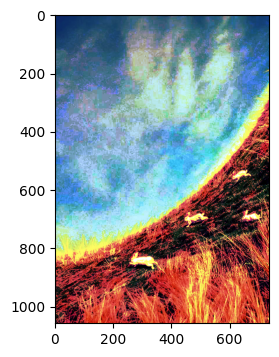

In [ ]:
background = plt.imread("Assets/background.png")

if background.max() <= 1.0:
    background = (background * 255).astype(np.uint8)

swapped = background.copy()
swapped[:,:,0] = background[:,:,2]
swapped[:,:,2] = background[:,:,0]

plt.figure(figsize=(5,4))
plt.imshow(swapped)
plt.show()

## Pemisahan Channel RGB

Setelah manipulasi channel dilakukan, citra swapped dipisahkan menjadi tiga channel warna secara individual, yaitu Red (R), Green (G), dan Blue (B). Setiap channel merepresentasikan intensitas warna masing-masing pada setiap piksel. Ketiga channel tersebut kemudian divisualisasikan secara terpisah menggunakan colormap yang sesuai (Reds, Greens, Blues) agar distribusi intensitas tiap channel dapat diamati dengan lebih jelas.

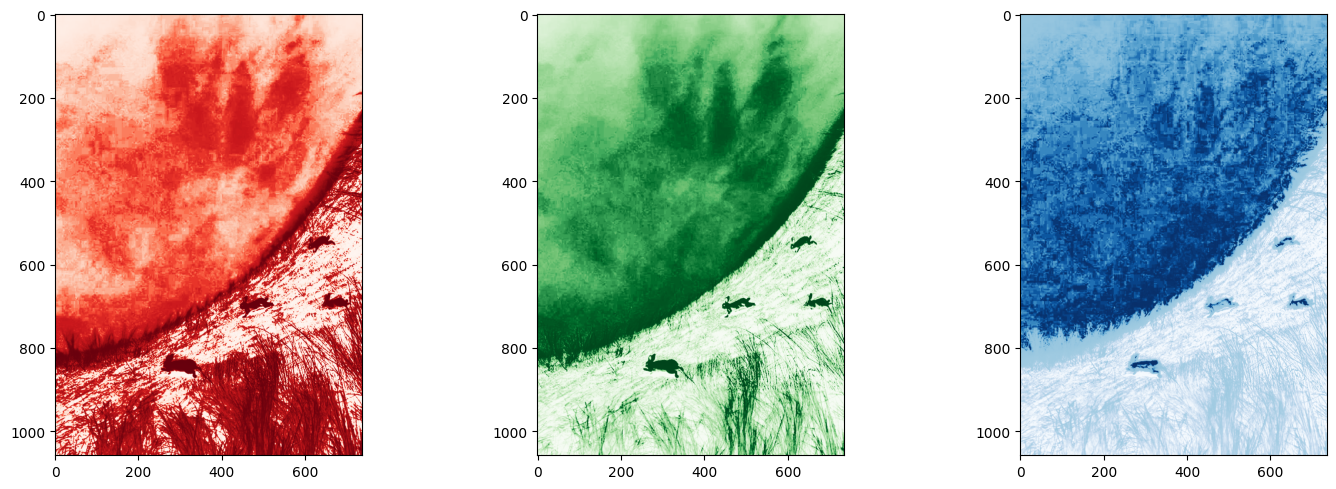

In [28]:
R = swapped[:, :, 0]
G = swapped[:, :, 1]
B = swapped[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R, cmap='Reds')
axes[1].imshow(G, cmap='Greens')
axes[2].imshow(B, cmap='Blues')
plt.tight_layout()
plt.show()

## Visualisasi Histogram RGB

Setelah pemisahan channel, histogram dari masing-masing channel R, G, dan B dihitung dan divisualisasikan. Histogram menampilkan distribusi jumlah piksel terhadap nilai intensitas (0–255). Dari histogram ini dapat diketahui apakah suatu channel memiliki distribusi yang merata, condong ke nilai gelap, atau condong ke nilai terang. Visualisasi dilakukan secara berdampingan untuk memudahkan perbandingan distribusi intensitas antar channel.

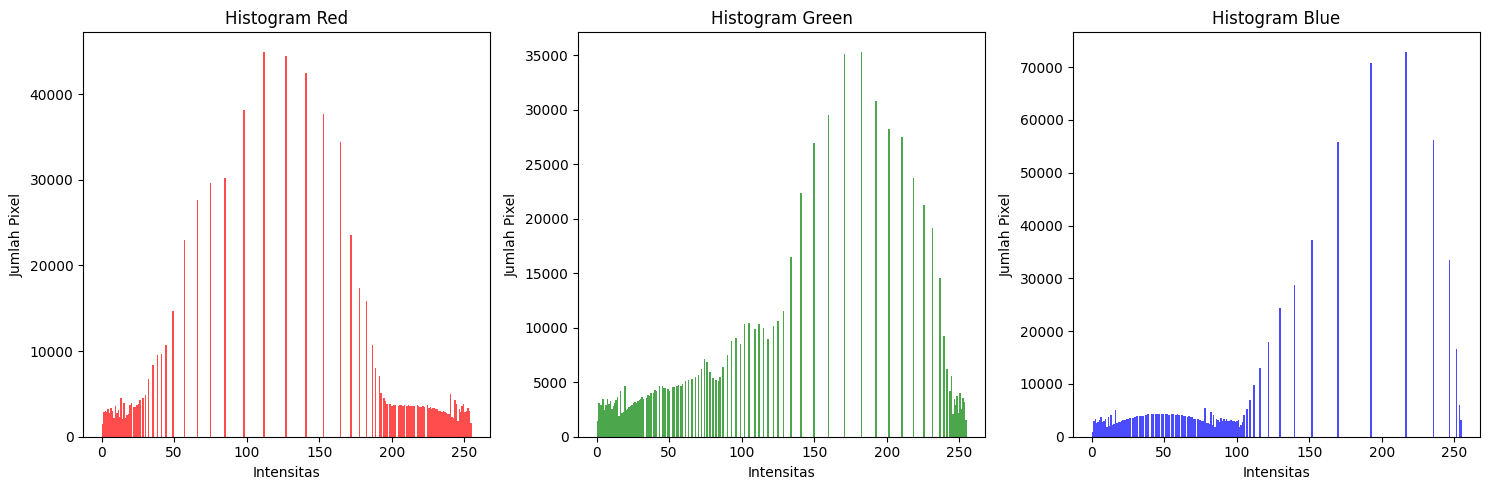

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(R.flatten(), bins=256, color='red', alpha=0.7)
axes[0].set_title('Histogram Red')
axes[0].set_xlabel('Intensitas')
axes[0].set_ylabel('Jumlah Pixel')

axes[1].hist(G.flatten(), bins=256, color='green', alpha=0.7)
axes[1].set_title('Histogram Green')
axes[1].set_xlabel('Intensitas')
axes[1].set_ylabel('Jumlah Pixel')

axes[2].hist(B.flatten(), bins=256, color='blue', alpha=0.7)
axes[2].set_title('Histogram Blue')
axes[2].set_xlabel('Intensitas')
axes[2].set_ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

## Histogram Specification

Pada tahap ini dilakukan histogram specification, yaitu proses penyesuaian distribusi intensitas citra sumber agar mendekati distribusi intensitas citra referensi. Fungsi histogram_specification() bekerja dengan menghitung CDF (Cumulative Distribution Function) dari histogram sumber dan referensi, lalu membuat tabel lookup yang memetakan nilai intensitas sumber ke nilai yang sesuai pada referensi. Proses ini diterapkan secara terpisah pada tiap channel R, G, dan B sehingga warna hasil keluaran menyerupai karakteristik warna citra referensi.

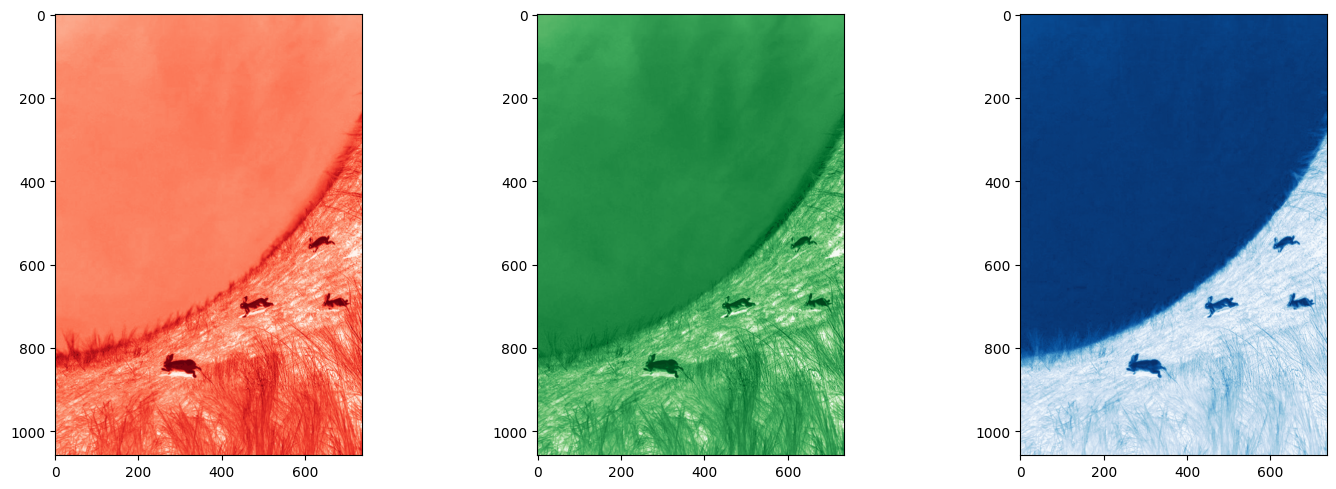

In [32]:
def histogram_specification(source, reference):
    src_hist, _ = np.histogram(source.flatten(), 256, [0, 256])
    ref_hist, _ = np.histogram(reference.flatten(), 256, [0, 256])
    
    src_cdf = src_hist.cumsum()
    src_cdf = (src_cdf - src_cdf.min()) * 255 / (src_cdf.max() - src_cdf.min())
    
    ref_cdf = ref_hist.cumsum()
    ref_cdf = (ref_cdf - ref_cdf.min()) * 255 / (ref_cdf.max() - ref_cdf.min())
    
    lookup = np.zeros(256, dtype=np.uint8)
    for src_val in range(256):
        diff = np.abs(ref_cdf - src_cdf[src_val])
        lookup[src_val] = np.argmin(diff)
    
    return lookup[source]

R_spec = histogram_specification(R, red)
G_spec = histogram_specification(G, green)
B_spec = histogram_specification(B, blue)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R_spec, cmap='Reds')
axes[1].imshow(G_spec, cmap='Greens')
axes[2].imshow(B_spec, cmap='Blues')
plt.tight_layout()
plt.show()

## Visualisasi Histogram Citra Referensi

Setelah histogram specification diterapkan, histogram dari citra referensi (channel red, green, blue) divisualisasikan untuk dibandingkan dengan histogram citra sumber sebelumnya. Dari visualisasi ini dapat diamati perbedaan distribusi intensitas antara citra sumber dan referensi, sekaligus memverifikasi bahwa proses histogram specification telah berhasil menyesuaikan distribusi intensitas citra sumber mendekati distribusi citra referensi.

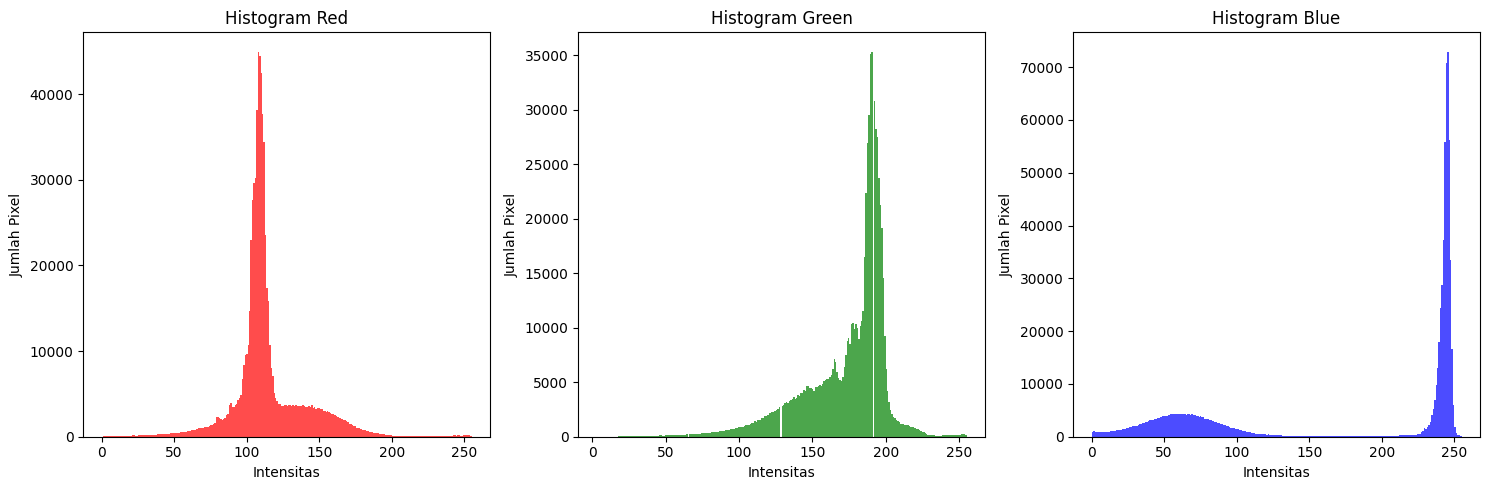

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(red.flatten(), bins=256, color='red', alpha=0.7)
axes[0].set_title('Histogram Red')
axes[0].set_xlabel('Intensitas')
axes[0].set_ylabel('Jumlah Pixel')

axes[1].hist(green.flatten(), bins=256, color='green', alpha=0.7)
axes[1].set_title('Histogram Green')
axes[1].set_xlabel('Intensitas')
axes[1].set_ylabel('Jumlah Pixel')

axes[2].hist(blue.flatten(), bins=256, color='blue', alpha=0.7)
axes[2].set_title('Histogram Blue')
axes[2].set_xlabel('Intensitas')
axes[2].set_ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

## Visualisasi Hasil Histogram Specification per Channel

Hasil histogram specification pada tiap channel R, G, dan B divisualisasikan kembali secara terpisah menggunakan colormap yang sesuai. Visualisasi ini bertujuan untuk mengamati secara visual perubahan distribusi warna pada masing-masing channel setelah proses penyesuaian histogram dilakukan. Dibandingkan dengan visualisasi channel sebelumnya, tampilan warna pada tahap ini telah mengalami penyesuaian yang mencerminkan karakteristik distribusi intensitas citra referensi.

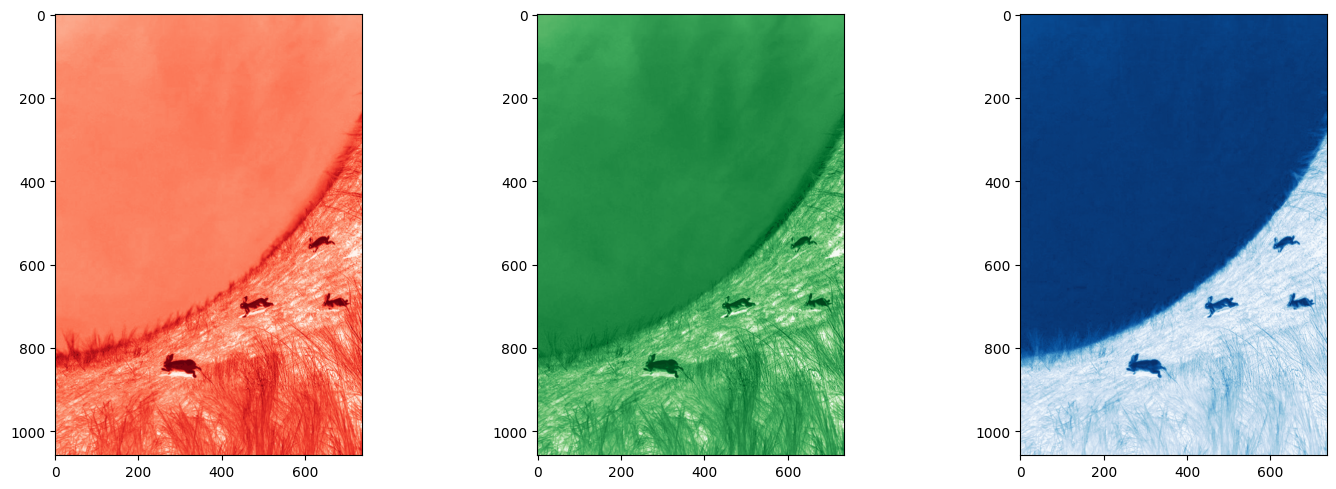

In [37]:
R_spec = histogram_specification(R, red)
G_spec = histogram_specification(G, green)
B_spec = histogram_specification(B, blue)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R_spec, cmap='Reds')
axes[1].imshow(G_spec, cmap='Greens')
axes[2].imshow(B_spec, cmap='Blues')

plt.tight_layout()
plt.show()

## Penggabungan Channel Hasil Specification

Ketiga channel hasil histogram specification (R_spec, G_spec, B_spec) digabungkan kembali menjadi satu citra berwarna menggunakan np.stack() pada axis ke-2. Hasilnya adalah citra background yang telah mengalami penyesuaian warna secara menyeluruh sesuai dengan distribusi referensi. Citra ini kemudian ditampilkan sebagai hasil akhir dari proses histogram specification pada citra latar belakang.

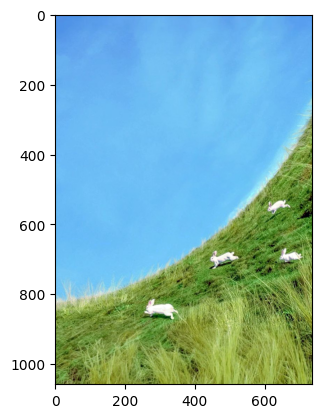

In [41]:
result = np.stack([R_spec, G_spec, B_spec], axis=2)

plt.imshow(result)
plt.show()

## Citra Foreground

Pada tahap ini, citra foreground yang memiliki 4 channel (RGBA) diproses untuk memisahkan objek dari latar belakang transparan. Channel alpha digunakan sebagai mask, piksel dengan nilai alpha 0 (transparan) diubah menjadi hitam (0, 0, 0), sementara piksel objek tetap dipertahankan. Hasilnya adalah citra foreground dengan latar belakang hitam yang siap untuk digabungkan dengan citra background.

(529, 368, 3)


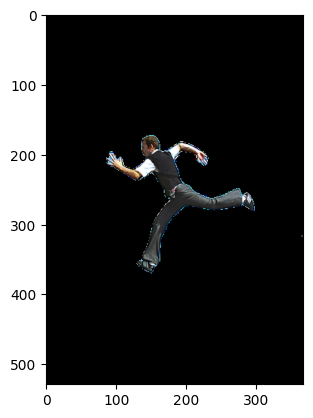

In [48]:
alpha = foreground[:, :, 3]
foreground_black = foreground[:, :, :3].copy()
foreground_black[alpha == 0] = [0, 0, 0]

print(foreground_black.shape)
plt.imshow(foreground_black)
plt.show()

## Dilasi Citra RGB

Kode ini digunakan untuk melakukan proses dilasi pada citra RGB menggunakan fungsi cv2.dilate() dari library OpenCV. Proses dilasi diterapkan secara terpisah pada channel merah, hijau, dan biru menggunakan kernel berukuran 3x3, sehingga objek pada citra menjadi lebih tebal dan area kecil yang kosong dapat tertutup. Setelah semua channel diproses, ketiganya digabung kembali menjadi citra berwarna utuh menggunakan np.stack(). Hasil akhir kemudian divisualisasikan menggunakan matplotlib untuk menampilkan setiap channel hasil dilasi beserta citra RGB akhirnya.

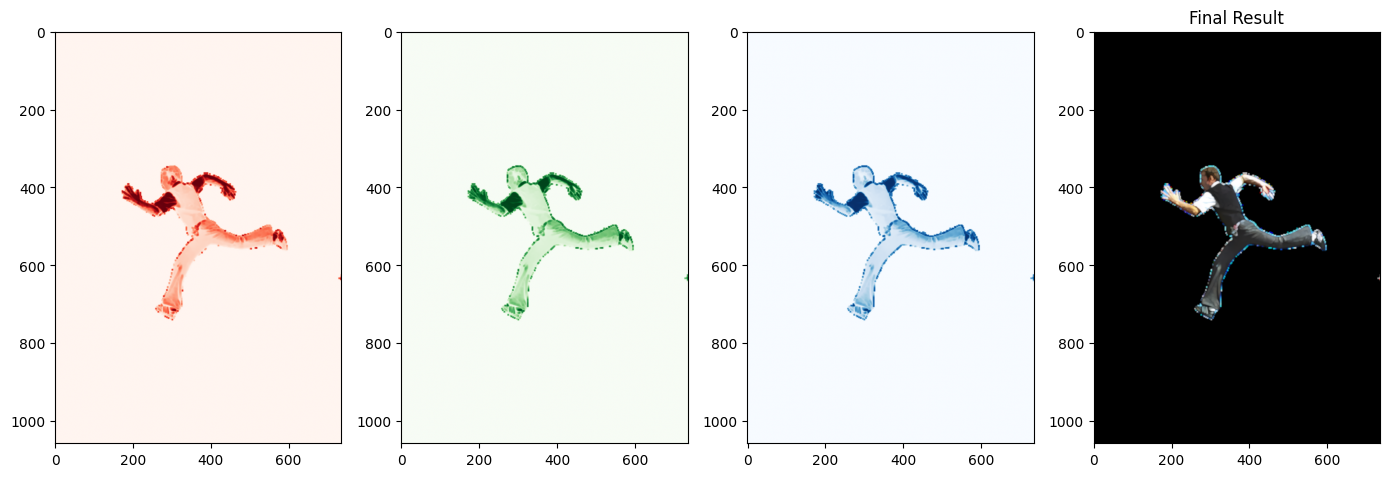

In [62]:
kernel = np.ones((3, 3), np.uint8)

R_dilated = cv2.dilate(foreground_resized[:,:,0], kernel, iterations=1)
G_dilated = cv2.dilate(foreground_resized[:,:,1], kernel, iterations=1)
B_dilated = cv2.dilate(foreground_resized[:,:,2], kernel, iterations=1)

foreground_dilated = np.stack([R_dilated, G_dilated, B_dilated], axis=2)

fig, axes = plt.subplots(1, 4, figsize=(14, 6))

axes[0].imshow(R_dilated, cmap='Reds')
axes[1].imshow(G_dilated, cmap='Greens')
axes[2].imshow(B_dilated, cmap='Blues')
axes[3].imshow(foreground_dilated)
axes[3].set_title('Final Result')

plt.tight_layout()
plt.show()

## Proses Composite Citra

Tahap ini digunakan untuk menggabungkan citra hasil dilasi dengan citra latar menggunakan teknik composite image. Variabel composite dibuat sebagai salinan dari citra result, kemudian dibuat mask menggunakan np.any() untuk mendeteksi bagian foreground yang memiliki nilai piksel lebih dari nol. Area yang terdeteksi pada mask akan diganti dengan piksel dari foreground_dilated, sehingga objek foreground dapat ditempelkan ke citra utama. Hasil akhirnya ditampilkan menggunakan matplotlib, dan ukuran citra dicek menggunakan composite.shape.

(1058, 736, 3)


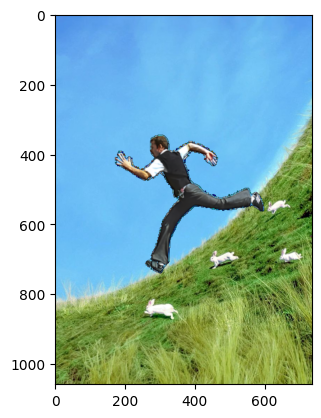

In [ ]:
composite = result.copy()

mask = np.any(foreground_dilated > 0, axis=2)
composite[mask] = foreground_dilated[mask]

print(composite.shape)
plt.imshow(composite)
plt.show()

## Histogram Bagian Tengah Citra

Bagian ini menampilkan histogram dari citra tengah menggunakan matplotlib. Fungsi flatten() mengubah data citra menjadi satu dimensi agar seluruh nilai intensitas piksel dapat dihitung frekuensinya. Histogram ditampilkan dengan 256 bin yang mewakili rentang intensitas piksel dari 0–255, dengan warna merah dan transparansi tertentu agar lebih mudah dibaca.

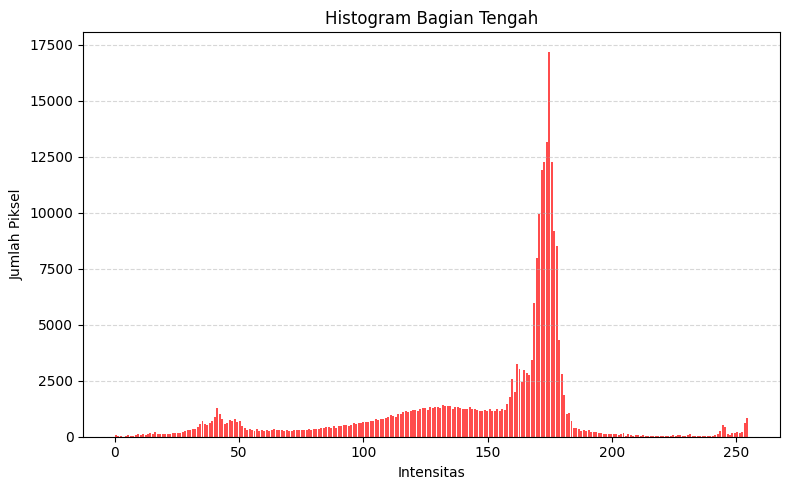

In [84]:
plt.figure(figsize=(8, 5))
plt.hist(tengah.flatten(), bins=256, color='red', alpha=0.7, rwidth=0.8)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Pemotongan Citra Menjadi Tiga Bagian

Membagi citra composite menjadi tiga bagian secara vertikal, yaitu bagian kiri, tengah, dan kanan. Ukuran tinggi dan lebar citra diambil menggunakan composite.shape, kemudian lebar citra dibagi menjadi tiga bagian menggunakan slicing array. Setiap bagian citra disimpan ke dalam variabel left, middle, dan right. Hasil pembagian tersebut kemudian ditampilkan menggunakan matplotlib dalam tiga subplot agar masing-masing bagian citra dapat diamati secara terpisah.

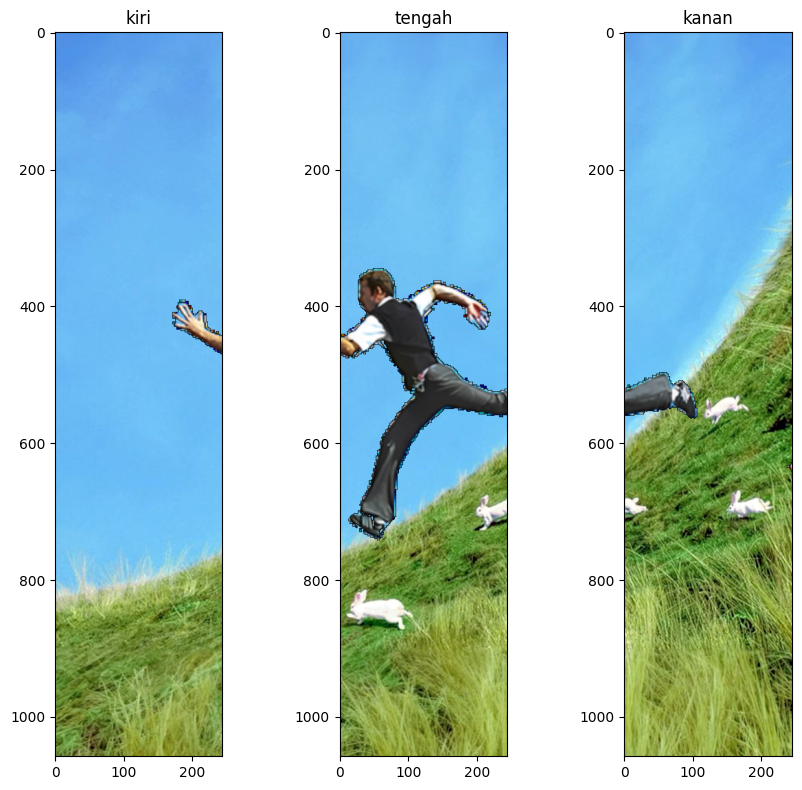

In [106]:
height, width, _ = composite.shape

left   = composite[:, :width//3, :]
middle = composite[:, width//3 : 2*width//3, :]
right  = composite[:, 2*width//3:, :]

fig, axes = plt.subplots(1, 3, figsize=(9, 8))

axes[0].imshow(left)
axes[0].set_title('kiri')

axes[1].imshow(middle)
axes[1].set_title('tengah')

axes[2].imshow(right)
axes[2].set_title('kanan')

plt.tight_layout()
plt.show()

## Histogram Grayscale Bagian Tengah

Kode ini digunakan untuk mengubah bagian tengah citra menjadi grayscale menggunakan fungsi cv2.cvtColor(). Setelah citra berubah menjadi grayscale, histogram intensitas piksel ditampilkan menggunakan matplotlib. Fungsi flatten() digunakan agar seluruh nilai piksel dapat dihitung distribusinya dalam 256 tingkat intensitas. Histogram ini membantu melihat persebaran tingkat kecerahan pada citra grayscale bagian tengah, sehingga analisis kontras dan pencahayaan gambar menjadi lebih mudah dilakukan.

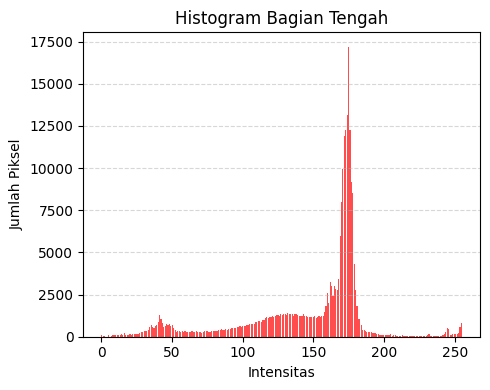

In [120]:
tengah_gray = cv2.cvtColor(middle, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5, 4))
plt.hist(tengah_gray.flatten(), bins=256, color='red', alpha=0.7, rwidth=0.8)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Ekualisasi Histogram pada Citra Tengah

Tahap ini melakukan proses histogram equalization pada bagian tengah citra guna meningkatkan kontras gambar. Awalnya citra middle diubah menjadi grayscale menggunakan cv2.cvtColor(), lalu dilakukan ekualisasi histogram dengan cv2.equalizeHist(). Hasil grayscale yang telah diekualisasi kemudian dikonversi kembali menjadi RGB. Selain itu, proses equalization juga diterapkan secara terpisah pada setiap channel warna merah, hijau, dan biru, kemudian digabung kembali menggunakan np.stack(). Hasil akhirnya divisualisasikan menggunakan matplotlib untuk menampilkan tiap channel warna serta citra hasil equalization berwarna.

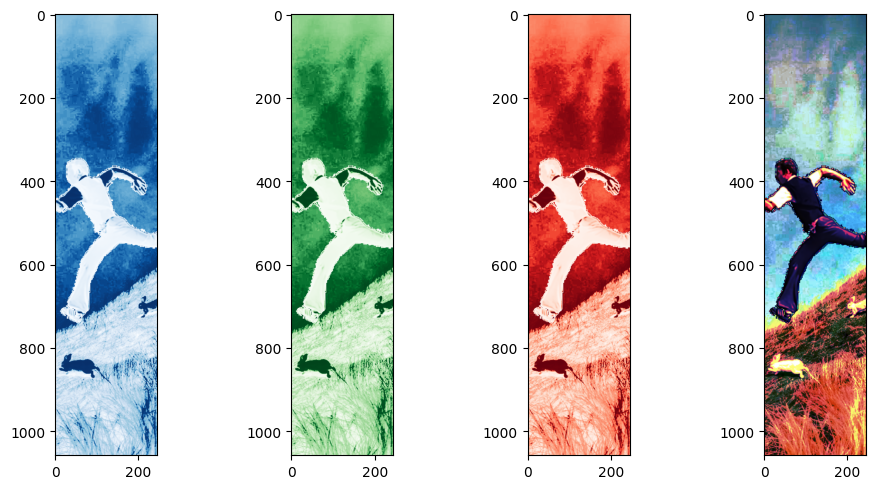

In [121]:
middle_gray = cv2.cvtColor(middle, cv2.COLOR_RGB2GRAY)
middle_eq = cv2.equalizeHist(middle_gray)
middle_eq_rgb = cv2.cvtColor(middle_eq, cv2.COLOR_GRAY2RGB)

R_mid = middle_eq_rgb[:, :, 0]
G_mid = middle_eq_rgb[:, :, 1]
B_mid = middle_eq_rgb[:, :, 2]

R_eq = cv2.equalizeHist(middle[:, :, 0])
G_eq = cv2.equalizeHist(middle[:, :, 1])
B_eq = cv2.equalizeHist(middle[:, :, 2])
middle_eq_color = np.stack([R_eq, G_eq, B_eq], axis=2)

fig, axes = plt.subplots(1, 4, figsize=(10, 5))

axes[0].imshow(B_mid, cmap='Blues')
axes[1].imshow(G_mid, cmap='Greens')
axes[2].imshow(R_mid, cmap='Reds')
axes[3].imshow(middle_eq_color)

plt.tight_layout()
plt.show()

## Histogram Setelah Histogram Equalization

Menampilkan histogram citra setelah proses histogram equalization dilakukan. Citra middle_eq_color terlebih dahulu diubah menjadi grayscale menggunakan cv2.cvtColor() agar distribusi intensitas piksel lebih mudah dianalisis. Setelah itu, histogram ditampilkan menggunakan matplotlib dengan 256 bin untuk menunjukkan persebaran nilai intensitas dari 0–255. Histogram hasil equalization biasanya terlihat lebih menyebar dibanding sebelumnya, yang menandakan kontras citra telah meningkat dan detail gambar menjadi lebih jelas.

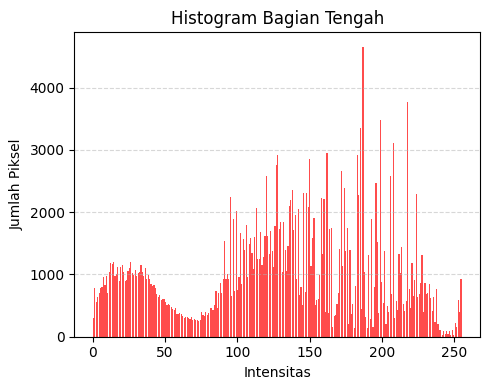

In [122]:
middle_eq_gray = cv2.cvtColor(middle_eq_color, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5, 4))
plt.hist(middle_eq_gray.flatten(), bins=256, color='red', alpha=0.7, rwidth=0.8)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Penggabungan Citra Akhir

Bagian ini menggabungkan kembali bagian kiri, tengah, dan kanan citra menjadi satu gambar utuh menggunakan np.concatenate(). Bagian tengah yang telah mengalami proses histogram equalization (middle_eq_color) digabung dengan bagian kiri (left) dan kanan (right) pada sumbu horizontal (axis=1). Hasil akhirnya disimpan dalam variabel final dan ditampilkan menggunakan matplotlib, sehingga perubahan kontras pada bagian tengah citra dapat terlihat secara langsung dibanding bagian lainnya.

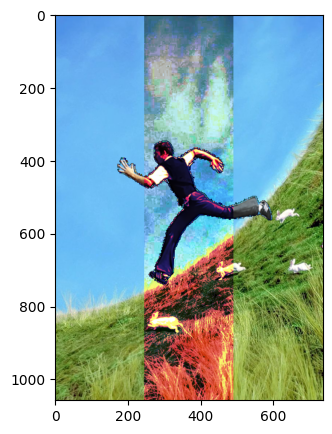

In [119]:
final = np.concatenate([left, middle_eq_color, right], axis=1)

plt.figure(figsize=(8, 5))
plt.imshow(final)
plt.show()

## Histogram Citra Akhir

Citra final terlebih dahulu diubah menjadi grayscale menggunakan cv2.cvtColor() agar distribusi intensitas piksel dapat dianalisis dengan lebih mudah. Selanjutnya, histogram ditampilkan menggunakan matplotlib dengan 256 bin untuk menunjukkan persebaran nilai intensitas piksel pada citra akhir. Histogram ini membantu melihat perubahan kontras dan distribusi kecerahan gambar setelah bagian tengah citra mengalami proses histogram equalization.

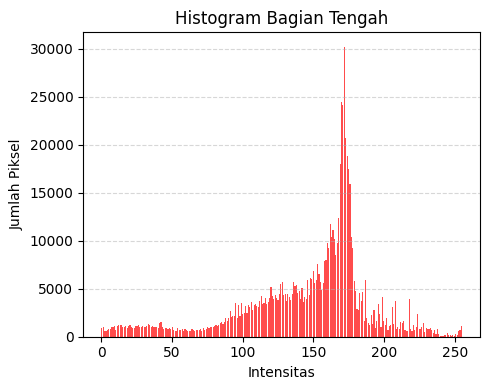

In [123]:
final_gray = cv2.cvtColor(final, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5, 4))
plt.hist(final_gray.flatten(), bins=256, color='red', alpha=0.7, rwidth=0.8)
plt.title('Histogram Bagian Tengah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ANALISIS DAN KESIMPULAN

Berdasarkan rangkaian proses pada proyek Dunia Ilusi Citra, dilakukan berbagai teknik pengolahan citra seperti pemisahan channel RGB, analisis histogram, spesifikasi histogram menggunakan citra target, dilasi, penggabungan citra, hingga histogram equalization pada bagian tengah gambar. Setiap tahapan bertujuan memperbaiki distribusi warna, pencahayaan, dan kontras agar citra terlihat lebih seimbang dan natural. Hasil akhir menunjukkan bahwa proses pengolahan citra berhasil meningkatkan kualitas visual gambar, ditandai dengan warna yang lebih hidup, objek yang lebih jelas, serta distribusi intensitas piksel yang lebih merata pada histogram.